In [1]:
import keras
import tensorflow as tf
import numpy as np
from keras import layers
from keras import ops
import matplotlib.pyplot as plt

In [2]:
mnist = tf.keras.datasets.fashion_mnist.load_data()
(X_train_full, y_train_full), (X_test, y_test) = mnist
X_train_full = X_train_full.astype(np.float32) / 255
X_test = X_test.astype(np.float32) / 255
X_train, X_valid = X_train_full[:-5000], X_train_full[-5000:]
y_train, y_valid = y_train_full[:-5000], y_train_full[-5000:]

In [3]:
#Source: https://keras.io/examples/generative/dcgan_overriding_train_step/

class GAN(keras.Model):
    def __init__(self, discriminator, generator, latent_dim):
        super().__init__()
        self.discriminator = discriminator
        self.generator = generator
        self.latent_dim = latent_dim
        self.seed_generator = keras.random.SeedGenerator(1337)

    def compile(self, d_optimizer, g_optimizer, loss_fn):
        super().compile()
        self.d_optimizer = d_optimizer
        self.g_optimizer = g_optimizer
        self.loss_fn = loss_fn
        self.d_loss_metric = keras.metrics.Mean(name="d_loss")
        self.g_loss_metric = keras.metrics.Mean(name="g_loss")

    @property
    def metrics(self):
        return [self.d_loss_metric, self.g_loss_metric]

    def train_step(self, real_images):
       #sample random points in the latent space
       batch_size = ops.shape(real_images)[0]
       random_latent_vectors = keras.random.normal(
           shape = (batch_size, self.latent_dim)
       )

       #create images out of random vectors
       generated_images = self.generator(random_latent_vectors)

       #combine with real images
       combined_images = ops.concatenate([generated_images, real_images], axis = 0)

       labels = ops.concatenate(
           [ops.ones((batch_size, 1)), ops.zeros((batch_size, 1))], axis = 0
       )
       #add noise to the labels - important trick!
       #basically makes sure the discriminator is not perfect
       #so the generator has a chance to learn
       labels += 0.05*tf.random.uniform(tf.shape(labels))

       #train the discriminator
       with tf.GradientTape() as tape:
          predictions = self.discriminator(combined_images)
          d_loss = self.loss_fn(labels, predictions)
       grads = tape.gradient(d_loss, self.discriminator.trainable_weights)
       self.d_optimizer.apply_gradients(zip(grads, self.discriminator.trainable_weights))

       #sample random points in latent space
       random_latent_vectors = keras.random.normal(
           shape = (batch_size, self.latent_dim)
       )

       #misleading labels saying "all real"
       misleading_labels = ops.zeros((batch_size, 1))

       #train generator (don't touch the weights of the discriminator)
       with tf.GradientTape() as tape:
          predictions = self.discriminator(self.generator(random_latent_vectors))
          g_loss = self.loss_fn(misleading_labels, predictions)
       grads = tape.gradient(g_loss, self.generator.trainable_weights)
       self.g_optimizer.apply_gradients(zip(grads, self.generator.trainable_weights))

       #update metrics
       self.d_loss_metric.update_state(d_loss)
       self.g_loss_metric.update_state(g_loss)
       return {
           "d_loss" : self.d_loss_metric.result(),
           "g_loss" : self.g_loss_metric.result(),
       }

In [4]:
latent_dim = 32

generator = keras.Sequential(
    [
        keras.Input(shape=(latent_dim,)),
        layers.Dense(100, activation="relu", kernel_initializer="he_normal"),
        layers.Dense(150, activation="relu", kernel_initializer="he_normal"),
        layers.Dense(28*28, activation="sigmoid"),
        layers.Reshape((28, 28)),
    ],
    name="generator",
)

discriminator = keras.Sequential(
    [
        keras.Input(shape=(28, 28)),
        layers.Flatten(),
        layers.Dense(150, activation="relu", kernel_initializer="he_normal"),
        layers.Dense(100, activation="relu", kernel_initializer="he_normal"),
        layers.Dense(1, activation="sigmoid"),
    ],
    name="discriminator",
)

epochs = 20

gan = GAN(discriminator=discriminator, generator=generator, latent_dim=latent_dim)
gan.compile(
    d_optimizer=keras.optimizers.RMSprop(learning_rate=0.001),
    g_optimizer=keras.optimizers.RMSprop(learning_rate=0.002),
    loss_fn=keras.losses.BinaryCrossentropy(),
)

gan.fit(X_train, epochs=epochs)

Epoch 1/20
1719/1719 ━━━━━━━━━━━━━━━━━━━━ 20s 6ms/step - d_loss: 0.6130 - g_loss: 1.4701
Epoch 2/20
1719/1719 ━━━━━━━━━━━━━━━━━━━━ 4s 2ms/step - d_loss: 0.5576 - g_loss: 1.2864
Epoch 3/20
1719/1719 ━━━━━━━━━━━━━━━━━━━━ 4s 2ms/step - d_loss: 0.5602 - g_loss: 1.2549
Epoch 4/20
1719/1719 ━━━━━━━━━━━━━━━━━━━━ 4s 2ms/step - d_loss: 0.5584 - g_loss: 1.2536
Epoch 5/20
1719/1719 ━━━━━━━━━━━━━━━━━━━━ 4s 2ms/step - d_loss: 0.5812 - g_loss: 1.2105
Epoch 6/20
1719/1719 ━━━━━━━━━━━━━━━━━━━━ 4s 2ms/step - d_loss: 0.6265 - g_loss: 1.1036
Epoch 7/20
1719/1719 ━━━━━━━━━━━━━━━━━━━━ 4s 2ms/step - d_loss: 0.6138 - g_loss: 1.1447
Epoch 8/20
1719/1719 ━━━━━━━━━━━━━━━━━━━━ 4s 2ms/step - d_loss: 0.6188 - g_loss: 1.1223
Epoch 9/20
1719/1719 ━━━━━━━━━━━━━━━━━━━━ 4s 2ms/step - d_loss: 0.6094 - g_loss: 1.1416
Epoch 10/20
1719/1719 ━━━━━━━━━━━━━━━━━━━━ 4s 2ms/step - d_loss: 0.5995 - g_loss: 1.1718
Epoch 11/20
1719/1719 ━━━━━━━━━━━━━━━━━━━━ 4s 2ms/step - d_loss: 0.5911 - g_loss: 1.1971
Epoch 12/20
1719/1719 ━━━━━━━

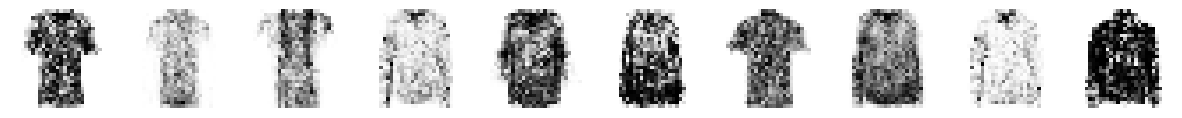

In [5]:
def plot_images(n_images, generator, latent_dim):
    random_latent_vectors = keras.random.normal(
            shape=(n_images, latent_dim), seed = keras.random.SeedGenerator(21)
        )

    images = generator(random_latent_vectors)

    fig = plt.figure(figsize=(n_images * 1.5, 4.5))
    for image_index in range(n_images):
        plt.subplot(1, n_images, 1 + image_index)
        plt.imshow(images[image_index], cmap="binary")
        plt.axis("off")
    plt.show()

plot_images(10, generator, latent_dim)